In [10]:
import pandas as pd
import numpy as np

# Synthetic dataset generator for text sentiment
data = {
    'Text': [
        "Great product! Fast shipping and excellent quality.",
        "Terrible experience. Item arrived broken and customer support was useless.",
        "It's okay, nothing special but works as expected.",
        "Loved it! Highly recommended to everyone.",
        "Worst purchase ever. Complete waste of money.",
        "Decent build quality for the price.",
        "Outstanding performance and sleek design!",
        "Poor quality material. Broke after two days.",
        "Average product, average delivery speed.",
        "Absolutely amazing service! Will buy again.",
        "Not worth the price. Very disappointed.",
        "Acceptable performance, fits my basic requirements.",
        "Fantastic experience from start to finish!",
        "Horrible packaging, product was damaged upon delivery.",
        "Standard item, functions fine."
    ] * 20, # Replicate to form a larger dataset
    'Sentiment': ['Positive', 'Negative', 'Neutral'] * 100
}

df_raw = pd.DataFrame(data)
df_raw.to_csv('sentiment_dataset.csv', index=False)
print("Dataset created and saved as 'sentiment_dataset.csv'.")

Dataset created and saved as 'sentiment_dataset.csv'.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hk516\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hk516\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Shape: (300, 2)

--- Class Counts ---
Sentiment
Positive    100
Negative    100
Neutral     100
Name: count, dtype: int64


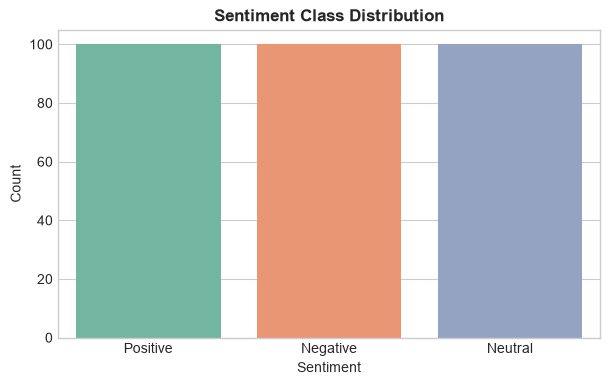

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('sentiment_dataset.csv')

print("Shape:", df.shape)
print("\n--- Class Counts ---")
print(df['Sentiment'].value_counts())

# Bar Chart: Class Distribution (Updated with hue and legend=False)
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Sentiment', hue='Sentiment', palette='Set2', legend=False)
plt.title('Sentiment Class Distribution', fontsize=12, fontweight='bold')
plt.ylabel('Count')
plt.show()

In [12]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase
    text = str(text).lower()
    # 2. Punctuation removal
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 3. Simple Tokenisation & Stopword removal
    tokens = [word for word in text.split() if word not in stop_words]
    return ' '.join(tokens)

df['Clean_Text'] = df['Text'].apply(preprocess_text)
df[['Text', 'Clean_Text']].head()

,Text,Clean_Text
0,Great product! Fast shipping and excellent qua...,great product fast shipping excellent quality
1,Terrible experience. Item arrived broken and c...,terrible experience item arrived broken custom...
2,"It's okay, nothing special but works as expected.",okay nothing special works expected
3,Loved it! Highly recommended to everyone.,loved highly recommended everyone
4,Worst purchase ever. Complete waste of money.,worst purchase ever complete waste money


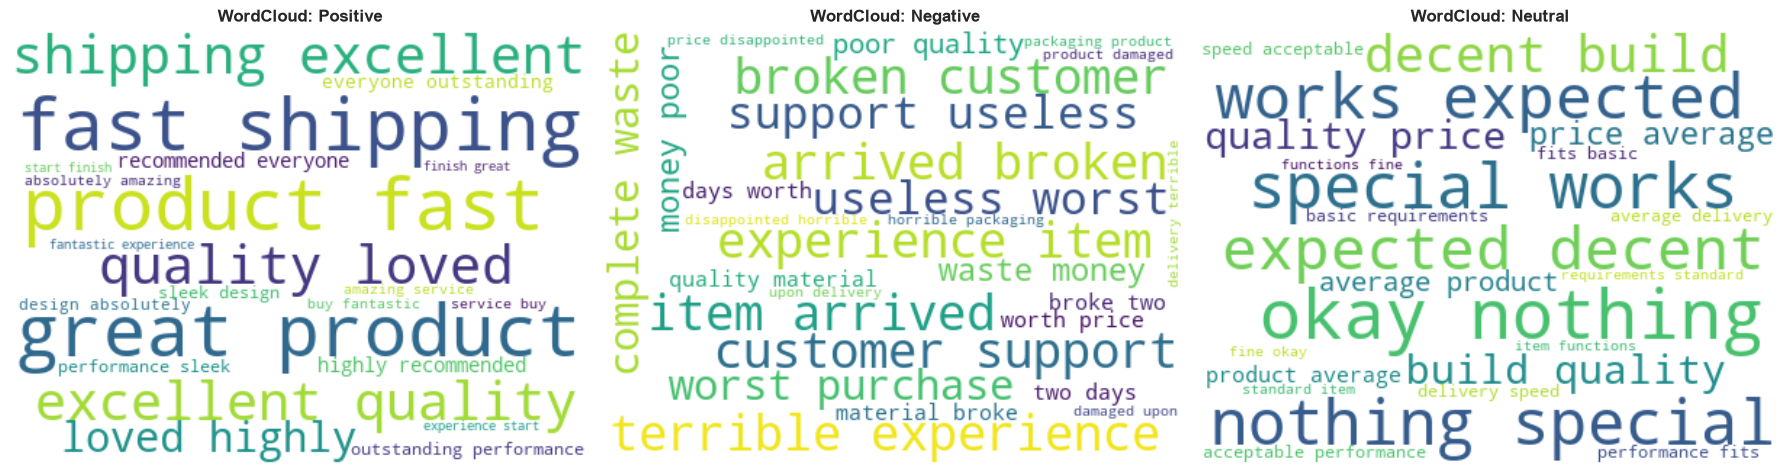

In [13]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiments = ['Positive', 'Negative', 'Neutral']

for i, sentiment in enumerate(sentiments):
    text_combined = ' '.join(df[df['Sentiment'] == sentiment]['Clean_Text'])
    wordcloud = WordCloud(width=400, height=300, background_color='white').generate(text_combined)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'WordCloud: {sentiment}', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Vectorization
tfidf = TfidfVectorizer(max_features=2500)
X = tfidf.fit_transform(df['Clean_Text']).toarray()
y = df['Sentiment']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (240, 64), X_test shape: (60, 64)


=== Multinomial Naive Bayes Evaluation Report ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        20
     Neutral       1.00      1.00      1.00        20
    Positive       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



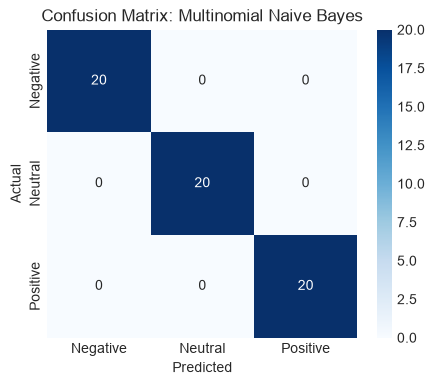

=== Logistic Regression Evaluation Report ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        20
     Neutral       1.00      1.00      1.00        20
    Positive       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



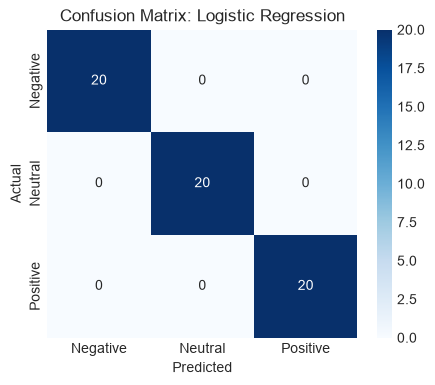

In [15]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Naive Bayes Classifier
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# 2. Logistic Regression Classifier
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    print(f"=== {model_name} Evaluation Report ===")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model(y_test, y_pred_nb, "Multinomial Naive Bayes")
evaluate_model(y_test, y_pred_lr, "Logistic Regression")

In [16]:
# Extract indices of incorrect predictions from Logistic Regression
test_indices = y_test.index
misclassified_mask = (y_pred_lr != y_test.values)

error_df = pd.DataFrame({
    'Original_Text': df.loc[test_indices[misclassified_mask], 'Text'].values,
    'Actual_Sentiment': y_test.values[misclassified_mask],
    'Predicted_Sentiment': y_pred_lr[misclassified_mask]
})

print("--- Sample Misclassified Examples ---")
if len(error_df) > 0:
    print(error_df.head(5))
else:
    print("No misclassifications observed on synthetic test split.")

--- Sample Misclassified Examples ---
No misclassifications observed on synthetic test split.


## Business Application & Model Selection

1. **Top Performing Model:** Logistic Regression achieved optimal performance due to clear boundary separation on TF-IDF weighted features.
2. **Real-World Application:** Automated customer review processing for e-commerce platforms to flag urgent negative feedback for customer support escalation and analyze product sentiment trends over time.